# Fig S10. representation drift2

In [1]:
from util import fisherztrans,stat_m_e,pair_test,sig,color_inv_alpha,corr_batch_nan
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
from faceprf_figure_function import set_figure,set_ax,myviolinplot_ind,myviolinplot_pair,myviolinplot_multi
import pingouin
import statsmodels.formula.api as smf

# setting
nsubj = 8
npos = 16
task = ['Digit Task','Face Task']
roi_labels = ['V1','V2','V3','hV4','IOG','pFus','mFus']
nroi = len(roi_labels)
ntask = len(task)
num_nf=[[0,4],[5,9]]
nsample2 = nsubj * np.max(np.diff(num_nf))

cms=np.array([[255, 195, 73],[145, 115, 185]])/255

# data path
data_path = "../data/"


In [2]:
# ========= session-wise metrics ==========
data = np.load(data_path+'driftcheck_session_loo.npz')
logdfnorm_d_session = data['logdfnorm_d_session']
logullambda_d_session = data['logullambda_d_session']
logvals_d_session = data['logvals_d_session']
# d x subj x roi x task x nsession

deltalogdfnorm_d_session = -2*np.diff(logdfnorm_d_session,axis=-2)[...,0,:]
deltalogullambda_d_session = np.diff(logullambda_d_session,axis=-2)[...,0,:]
deltalogvals_d_session = -np.diff(logvals_d_session,axis=-2)[...,0,:]
# d x subj x roi x nsession

nf_i = 1 # far distance
deltalogdfnorm_session = np.nanmean(deltalogdfnorm_d_session[num_nf[nf_i][0]:num_nf[nf_i][1]],axis=0)
deltalogullambda_session = np.nanmean(deltalogullambda_d_session[num_nf[nf_i][0]:num_nf[nf_i][1]],axis=0)
deltalogvals_session = np.nanmean(deltalogvals_d_session[num_nf[nf_i][0]:num_nf[nf_i][1]],axis=0)
# subj x roi x session

# ========== session-pooled metrics ===========
deltaIlog_stw_d_subj = np.load(data_path+'LFI_separate.npz',allow_pickle=True)['deltaIlog_stw_d_subj']
deltaIlog_stw_subj = np.nanmean(deltaIlog_stw_d_subj[num_nf[nf_i][0]:num_nf[nf_i][1]],axis=0)
# subj x roi x metrics

ANOVA results: [[1.         1.         1.         1.         1.         1.
  1.        ]
 [1.         1.         1.         1.         1.         0.19328909
  0.73369973]
 [0.0866586  1.         1.         1.         1.         1.
  1.        ]]


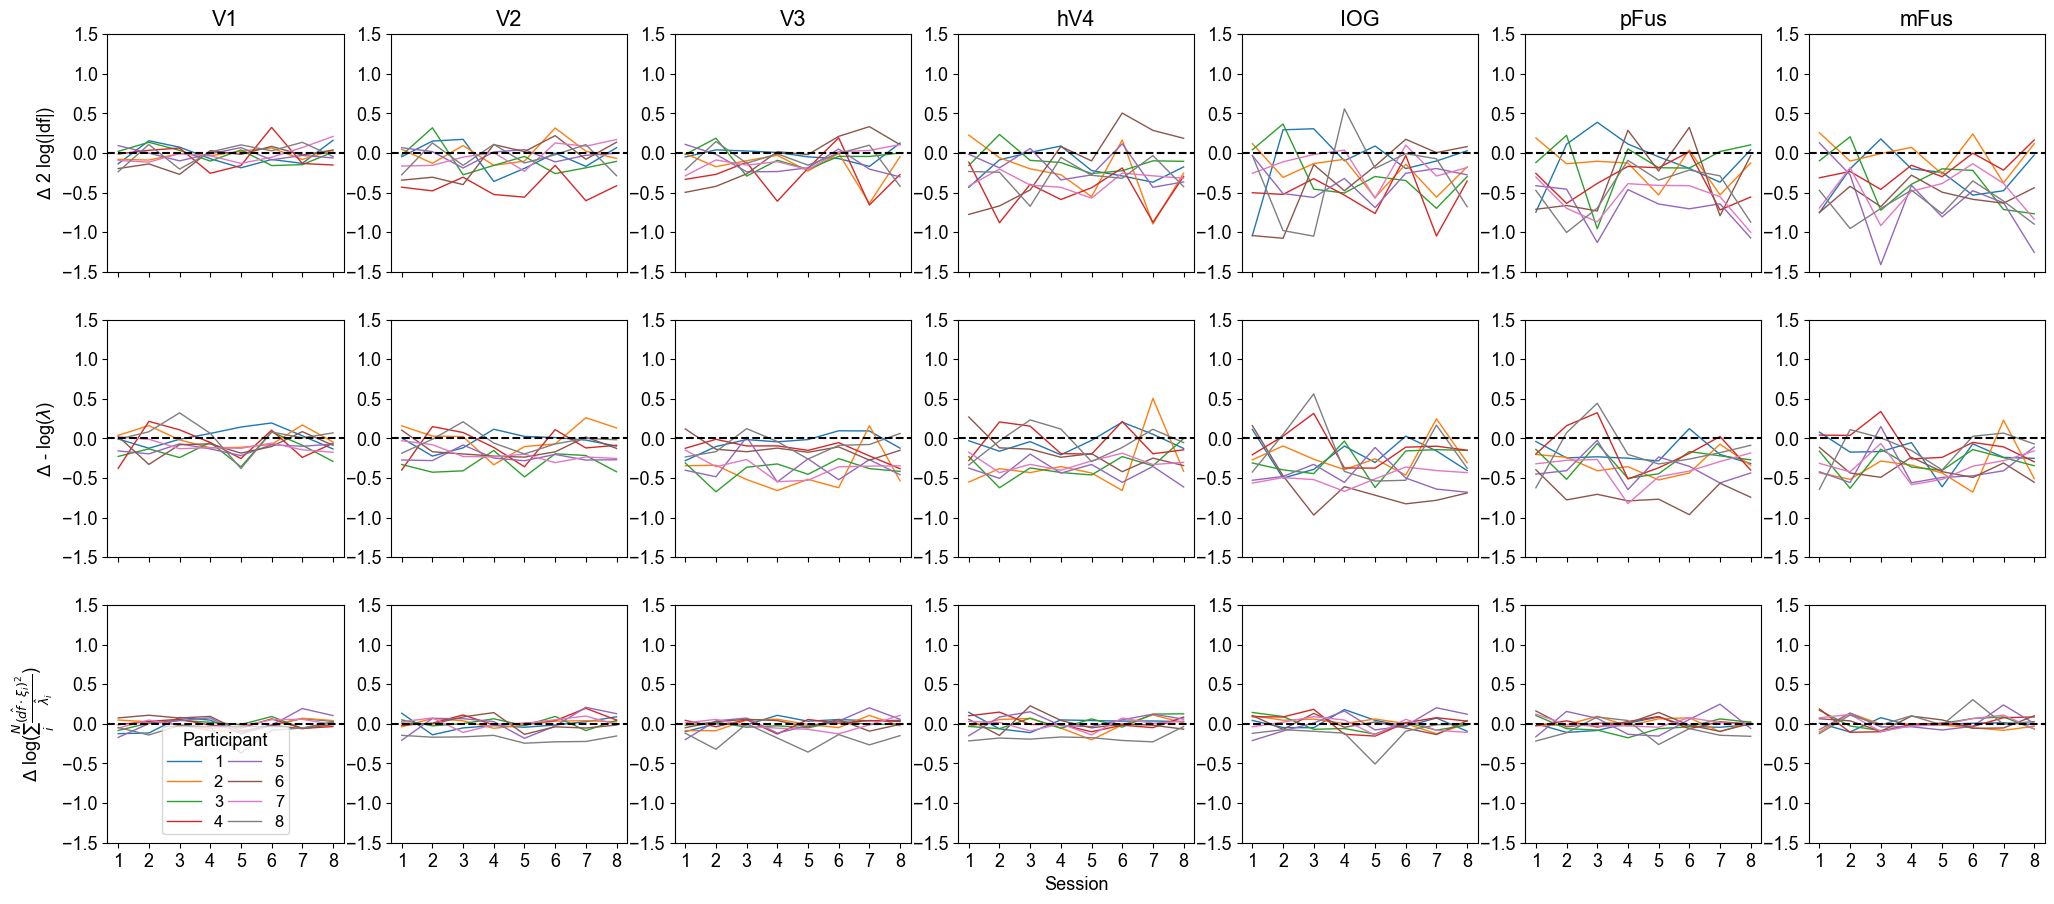

In [3]:
data_metric = np.stack([deltalogdfnorm_session,deltalogullambda_session, deltalogvals_session],axis=0)
# metric x subj x roi x session
metric_labels = [r'$\Delta$ 2 log(|df|)',r'$\Delta$ - log($\lambda$)',r'$\Delta$ log($\sum_i^N \frac{(\hat{df}\cdot\xi_i)^2}{\hat\lambda_i}$)']
colors = plt.get_cmap('tab10').colors # 10 colors

nsess = data_metric.shape[-1]

# plotting
set_figure()
plt.rcParams['figure.autolayout'] = False
fig,axes = plt.subplots(data_metric.shape[0],7,figsize=(25,3.5*data_metric.shape[0]),gridspec_kw={'wspace': 0.2,'hspace':0.2},sharex=True)#,sharey=True)
ylims = [[-1.5,1.5],[-1.5,1.5],[-1.5,1.5]]
for m_i in range(data_metric.shape[0]):


    for roi_i, roi in enumerate(roi_labels):
        ax = axes[m_i,roi_i]
        metric = data_metric[m_i,:,roi_i,:] # subj x session
        xx = np.zeros_like(metric)+np.arange(1,1+nsess)

        # session-wise
        for subj_i in range(metric.shape[0]):
            metric_rel = metric[subj_i,:]-deltaIlog_stw_subj[subj_i,roi_i,m_i]
            ax.plot(xx[subj_i], metric_rel,linewidth=1,color=colors[subj_i],alpha=1)
        
        ax.axhline(y=0,color='k',linestyle='--')

        ax.set_xticks(np.arange(1,nsess+1))
        ax.set_ylim(ylims[m_i][0],ylims[m_i][1])
        axes[0,roi_i].set_title(roi)
    axes[m_i,0].set_ylabel(metric_labels[m_i])
axes[-1,0].legend(['{}'.format(subj_i+1) for subj_i in range(nsubj)],title='Participant',
        labelspacing=0.3,ncol=2,columnspacing=0.3,borderpad=0.3,fontsize=12)
axes[-1,3].set_xlabel('Session')

fig.savefig('../figures/figS10-dirftsession-far.pdf', bbox_inches='tight')


ps = []
for m_i in range(data_metric.shape[0]):

    for roi_i, roi in enumerate(roi_labels):
        metric = data_metric[m_i,:,roi_i,:] # subj x session
        df = pd.DataFrame({
            'subject': np.repeat(np.arange(nsubj), nsess),
            'session': np.tile(np.arange(nsess), nsubj),
            'value': metric.flatten()
        })
        df = df.dropna()
        aov = pingouin.rm_anova(data=df, dv='value', within='session', subject='subject', detailed=True)
        ps.append(aov['p-unc'].iloc[0])

ps_f = multipletests(ps,method='bonferroni')[1]
ps_f = np.reshape(ps_f,[3,7])
print('ANOVA results: {}'.format(ps_f))

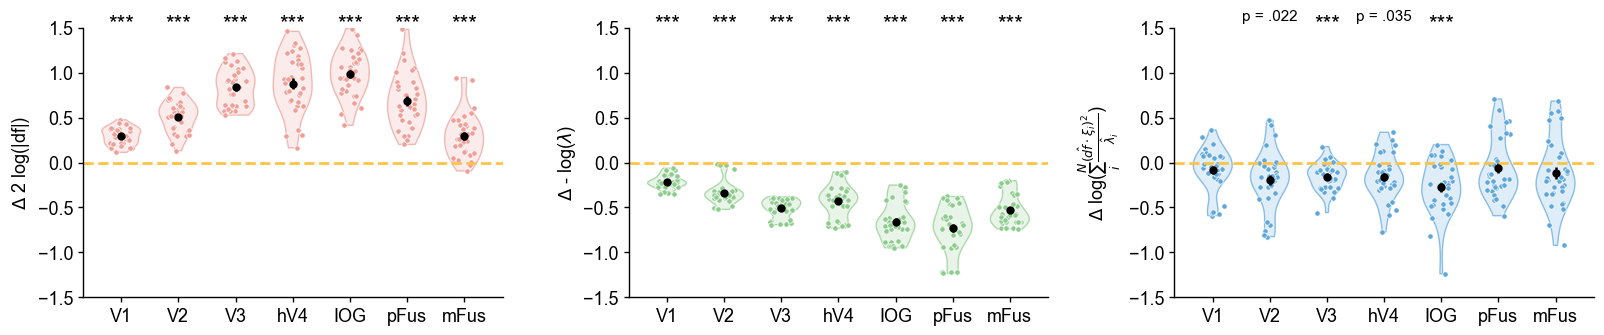

In [4]:
def metric_distancebin(metric_subj,nsample2,num_nf):
    nroi = metric_subj.shape[2]
    metric_subj_nf = np.zeros([nsample2,len(num_nf),nroi])*np.nan # 8subjects*4d x nnf x nroi
    for i in range(len(num_nf)):
        for roi_i in range(nroi):
            a = metric_subj[num_nf[i][0]:num_nf[i][1],:,roi_i].flatten()
            metric_subj_nf[:len(a),i,roi_i] = a

    return metric_subj_nf

nf_i = 1
deltalogdfnorm_d_subj = np.nanmean(deltalogdfnorm_d_session,axis=-1) # averaged across session
deltalogdfnorm_subj = metric_distancebin(deltalogdfnorm_d_subj,nsample2,num_nf)[:,nf_i,:]
deltalogullambda_d_subj = np.nanmean(deltalogullambda_d_session,axis=-1) # averaged across session
deltalogullambda_subj = metric_distancebin(deltalogullambda_d_subj,nsample2,num_nf)[:,nf_i,:]
deltalogvals_d_subj = np.nanmean(deltalogvals_d_session,axis=-1) # averaged across session
deltalogvals_subj = metric_distancebin(deltalogvals_d_subj,nsample2,num_nf)[:,nf_i,:]
# nsample2 x roi

data_metric_subj = np.stack([deltalogdfnorm_subj,deltalogullambda_subj, deltalogvals_subj],axis=0)
# metric x nsample2 x roi
metric_labels = [r'$\Delta$ 2 log(|df|)',r'$\Delta$ - log($\lambda$)',r'$\Delta$ log($\sum_i^N \frac{(\hat{df}\cdot\xi_i)^2}{\hat\lambda_i}$)']
cms=np.array([[255, 195, 73],[145, 115, 185]])/255 # 黄、紫
cms4=['#ed9f98','#8dcc8c','#5ea6db',cms[1]]

set_figure()
plt.rcParams['figure.autolayout'] = False
fig,axes = plt.subplots(1,len(metric_labels),figsize=(6.5*len(metric_labels),3.5),gridspec_kw={'wspace':0.3,'hspace':0.55})

pys = [[1.55],[1.55],[1.55]]
ylims = [[-1.5,1.5],[-1.5,1.5],[-1.5,1.5]]

ps = np.empty((data_metric_subj.shape[0],len(roi_labels)))
for m_i in range(data_metric_subj.shape[0]):
    for roi_i in range(len(roi_labels)):
        sts=pingouin.wilcoxon(data_metric_subj[m_i,:,roi_i],nan_policy='omit')
        ps[m_i,roi_i] = sts["p-val"].iloc[0]
ps = np.reshape(multipletests(ps.flatten(),method='bonferroni')[1],(data_metric_subj.shape[0],len(roi_labels)))
    

for m_i in range(data_metric_subj.shape[0]):

    ax = axes[m_i]
    set_ax(ax)
    myviolinplot_ind(ax, data_metric_subj[m_i,:], 'mean', 'sem', ps[m_i,:], pys[m_i],color=cms4[m_i])
    ax.set_xticklabels(roi_labels)
    ax.set_ylabel(metric_labels[m_i])
    ax.set_ylim(ylims[m_i])
    ax.axhline(y=0, color=cms[0], linestyle='--',linewidth=2,zorder=2, alpha=1)     # digit 

fig.savefig('../figures/figS10-dirftsession-seperate-far.pdf', bbox_inches='tight')
